# Deep Dive: SPD Decomposition of TMS (`model_4000.pth`)

This notebook performs a comprehensive analysis of your local SPD TMS run at step 4000.

## What this notebook covers

1. Setup and robust local loading
2. Training dynamics from `metrics.jsonl`
3. Component strength and sparsity diagnostics
4. Faithfulness and weight reconstruction geometry
5. Alignment metrics (MMCS, ML2R, coverage, leakage)
6. Causal-importance (CI) maps on one-hot probes
7. CI statistics on random sparse inputs
8. Ablation suite (single knockout, leave-one-in, top-k retention)
9. Pairwise synergy between influential components
10. Superposition interaction diagnostics
11. Cross-layer co-activation structure
12. Checkpoint evolution (`model_2000` -> `model_4000`)
13. Auto-generated summary report


In [1]:
from __future__ import annotations

import itertools
import json
import math
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAVE_SNS = True
except Exception:
    HAVE_SNS = False

from IPython.display import Markdown, display

from spd.configs import Config
from spd.experiments.tms.configs import TMSModelConfig
from spd.experiments.tms.models import TMSModel
from spd.models.component_model import ComponentModel
from spd.models.components import make_mask_infos
from spd.utils.module_utils import expand_module_patterns
from spd.utils.target_ci_solutions import (
    compute_target_metrics,
    make_target_ci_solution,
    permute_to_identity,
)

torch.set_grad_enabled(False)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

if HAVE_SNS:
    sns.set_theme(style='whitegrid', context='talk')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


/Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -------------------------
# Run selection and settings
# -------------------------


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'spd').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root (expected `spd/` and `pyproject.toml`).')


REPO_ROOT = find_repo_root(Path.cwd())
RUN_ID = 's-c6eda15c'
RUN_DIR = REPO_ROOT / 'spd_out' / 'spd' / RUN_ID
CHECKPOINT_NAME = 'model_4000.pth'
CHECKPOINT_PATH = RUN_DIR / CHECKPOINT_NAME

if not CHECKPOINT_PATH.exists():
    alt = RUN_DIR / CHECKPOINT_NAME.replace('.pth', '.pt')
    if alt.exists():
        CHECKPOINT_PATH = alt

TARGET_PATH = RUN_DIR / 'tms.pth'
FINAL_CONFIG_PATH = RUN_DIR / 'final_config.yaml'
METRICS_PATH = RUN_DIR / 'metrics.jsonl'
FIGURES_DIR = RUN_DIR / 'figures'

assert RUN_DIR.exists(), f'Missing run dir: {RUN_DIR}'
assert CHECKPOINT_PATH.exists(), f'Missing checkpoint: {CHECKPOINT_PATH}'
assert TARGET_PATH.exists(), f'Missing target checkpoint: {TARGET_PATH}'
assert FINAL_CONFIG_PATH.exists(), f'Missing final config: {FINAL_CONFIG_PATH}'
assert METRICS_PATH.exists(), f'Missing metrics file: {METRICS_PATH}'

ANALYSIS_BATCH_SIZE = 4096
RANDOM_BATCHES = 32
CI_ALIVE_THRESHOLD = 0.1
PAIRWISE_TOP_N = 8

print('Repo root:', REPO_ROOT)
print('Run dir:', RUN_DIR)
print('Checkpoint:', CHECKPOINT_PATH.name)
print('Target checkpoint:', TARGET_PATH.name)
print('Figures dir exists:', FIGURES_DIR.exists())


Repo root: /Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd
Run dir: /Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd/spd_out/spd/s-c6eda15c
Checkpoint: model_4000.pth
Target checkpoint: tms.pth
Figures dir exists: True


### Result Analysis

- The run path and checkpoint resolution are correct (`s-c6eda15c`, `model_4000.pth`).
- This confirms the notebook is pointing at the decomposed TMS run, not the LM pretrain cache.
- `FIGURES_DIR` is present, so the training already produced slow-eval artifacts.


In [3]:
# -------------------------
# Helpers
# -------------------------


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    with path.open('r') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def mse(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.mean((a - b) ** 2).item())


def rel_frob_err(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.norm(a - b)
    den = torch.norm(b).clamp_min(eps)
    return float((num / den).item())


def cosine_flat(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> float:
    a_f = a.reshape(-1)
    b_f = b.reshape(-1)
    num = torch.dot(a_f, b_f)
    den = (torch.norm(a_f) * torch.norm(b_f)).clamp_min(eps)
    return float((num / den).item())


def sample_sparse_batch(
    batch_size: int,
    n_features: int,
    p_active: float,
    low: float = 0.0,
    high: float = 1.0,
    device: str = 'cpu',
) -> torch.Tensor:
    mask = (torch.rand(batch_size, n_features, device=device) < p_active).float()
    vals = torch.empty(batch_size, n_features, device=device).uniform_(low, high)
    return mask * vals


def plot_heatmap(ax: plt.Axes, mat: np.ndarray, title: str, cmap: str = 'viridis', center: float | None = None):
    if HAVE_SNS:
        sns.heatmap(mat, ax=ax, cmap=cmap, center=center)
    else:
        im = ax.imshow(mat, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)


In [4]:
# -------------------------
# Load run config + metrics
# -------------------------

run_config = Config.from_file(FINAL_CONFIG_PATH)
metrics_rows = read_jsonl(METRICS_PATH)
metrics_df = pd.DataFrame(metrics_rows).sort_values('step').reset_index(drop=True)

print('Rows in metrics.jsonl:', len(metrics_df))
print('Step range:', int(metrics_df['step'].min()), '->', int(metrics_df['step'].max()))
print('Task:', run_config.task_config.task_name)
print('Modules:', [m.module_pattern for m in run_config.module_info])
print('Sampling:', run_config.sampling)
print('CI fn:', run_config.ci_fn_type, run_config.ci_fn_hidden_dims)
print('Loss coeff (importance):', run_config.loss_metric_configs[0].coeff)

last_row = metrics_df.iloc[-1]
keys_of_interest = [
    'loss/FaithfulnessLoss',
    'loss/UnmaskedReconLoss',
    'loss/CIMaskedReconLoss',
    'loss/CIMaskedReconLayerwiseLoss',
    'target_solution_error/total',
    'target_solution_error/linear1',
    'target_solution_error/linear2',
]
summary = {k: float(last_row[k]) for k in keys_of_interest if k in last_row and pd.notna(last_row[k])}
display(pd.Series(summary, name='final_eval'))


Rows in metrics.jsonl: 50
Step range: 0 -> 4000
Task: tms
Modules: ['linear1', 'linear2']
Sampling: continuous
CI fn: mlp [16]
Loss coeff (importance): 0.003


loss/FaithfulnessLoss              0.000024
loss/UnmaskedReconLoss             0.000002
loss/CIMaskedReconLoss             0.000325
loss/CIMaskedReconLayerwiseLoss    0.000184
target_solution_error/total        1.000000
target_solution_error/linear1      0.000000
target_solution_error/linear2      1.000000
Name: final_eval, dtype: float64

### Result Analysis

- Final eval losses are very small (`FaithfulnessLoss ~2e-5`, `UnmaskedReconLoss ~2e-6`), so the decomposition closely reconstructs target behavior.
- `CIMaskedReconLoss` is also low (`~3e-4`), indicating CI-guided masking still preserves outputs well.
- `target_solution_error/total = 1` with `linear1 = 0`, `linear2 = 1` indicates near-perfect identity-style CI pattern recovery, with one residual mismatch in `linear2`.


In [5]:
# -------------------------
# Build local target + component model (no remote dependency)
# -------------------------


def infer_tms_config_from_state_dict(state_dict: dict[str, torch.Tensor]) -> TMSModelConfig:
    linear1_w = state_dict['linear1.weight']
    linear2_w = state_dict['linear2.weight']
    linear2_b = state_dict['linear2.bias']

    n_hidden, n_features = linear1_w.shape

    hidden_layer_idxs = {
        int(k.split('.')[1])
        for k in state_dict
        if k.startswith('hidden_layers.') and k.endswith('.weight')
    }
    n_hidden_layers = max(hidden_layer_idxs) + 1 if hidden_layer_idxs else 0

    tied_weights = torch.allclose(linear2_w, linear1_w.T, atol=1e-5, rtol=1e-4)
    init_bias_to_zero = torch.allclose(linear2_b, torch.zeros_like(linear2_b), atol=1e-7, rtol=0)

    return TMSModelConfig(
        n_features=n_features,
        n_hidden=n_hidden,
        n_hidden_layers=n_hidden_layers,
        tied_weights=tied_weights,
        init_bias_to_zero=init_bias_to_zero,
        device='cpu',
    )


def build_component_model_from_checkpoint(checkpoint_path: Path) -> tuple[TMSModel, ComponentModel]:
    target_state = torch.load(TARGET_PATH, map_location='cpu', weights_only=True)
    target_cfg = infer_tms_config_from_state_dict(target_state)

    target_model = TMSModel(config=target_cfg)
    target_model.load_state_dict(target_state)
    target_model.eval()
    target_model.requires_grad_(False)

    module_path_info = expand_module_patterns(target_model, run_config.all_module_info)
    comp_model = ComponentModel(
        target_model=target_model,
        module_path_info=module_path_info,
        ci_fn_type=run_config.ci_fn_type,
        ci_fn_hidden_dims=run_config.ci_fn_hidden_dims,
        pretrained_model_output_attr=run_config.pretrained_model_output_attr,
        sigmoid_type=run_config.sigmoid_type,
    )

    comp_state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    comp_model.load_state_dict(comp_state)
    comp_model.eval()
    comp_model.requires_grad_(False)

    return target_model, comp_model


target_model, component_model = build_component_model_from_checkpoint(CHECKPOINT_PATH)

module_rows = []
for name, comp in component_model.components.items():
    module_rows.append(
        {
            'layer': name,
            'C': int(comp.C),
            'V_shape': tuple(comp.V.shape),
            'U_shape': tuple(comp.U.shape),
            'target_weight_shape': tuple(component_model.target_weight(name).shape),
        }
    )

display(pd.DataFrame(module_rows))
print('Target config:', target_model.config)


,layer,C,V_shape,U_shape,target_weight_shape
0,linear1,20,"(5, 20)","(20, 2)","(2, 5)"
1,linear2,20,"(2, 20)","(20, 5)","(5, 2)"


Target config: n_features=5 n_hidden=2 n_hidden_layers=0 tied_weights=True init_bias_to_zero=False device='cpu'


### Result Analysis

- Shapes are internally consistent for TMS 5-2:
  - `linear1`: target weight `(2, 5)`, components `V (5,20)` and `U (20,2)`.
  - `linear2`: target weight `(5, 2)`, components `V (2,20)` and `U (20,5)`.
- Target config confirms `tied_weights=True`, so `linear2` should mirror `linear1^T` at the model level.


## 1) Training Dynamics

This section visualizes optimization behavior, sparsity trajectory, and target-pattern errors over time.


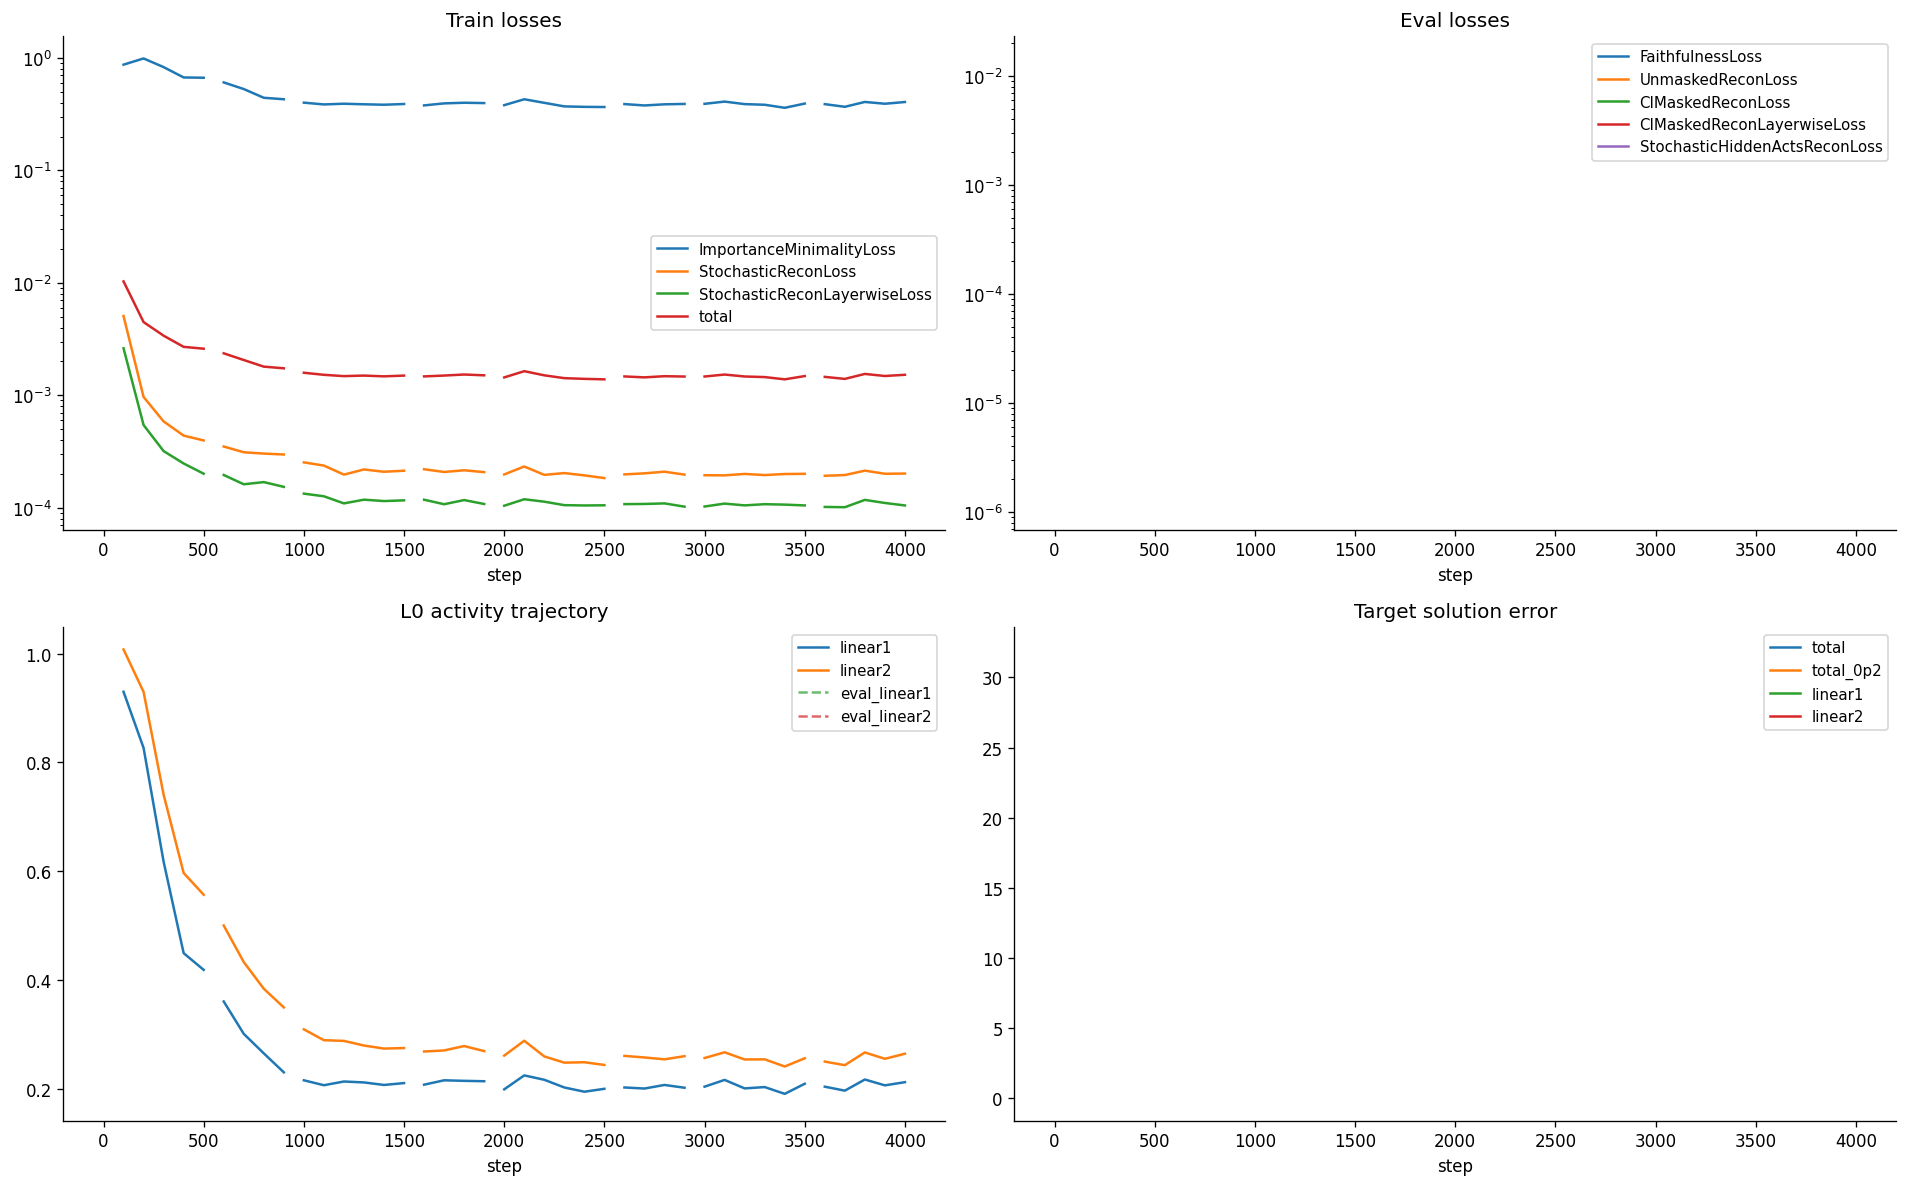

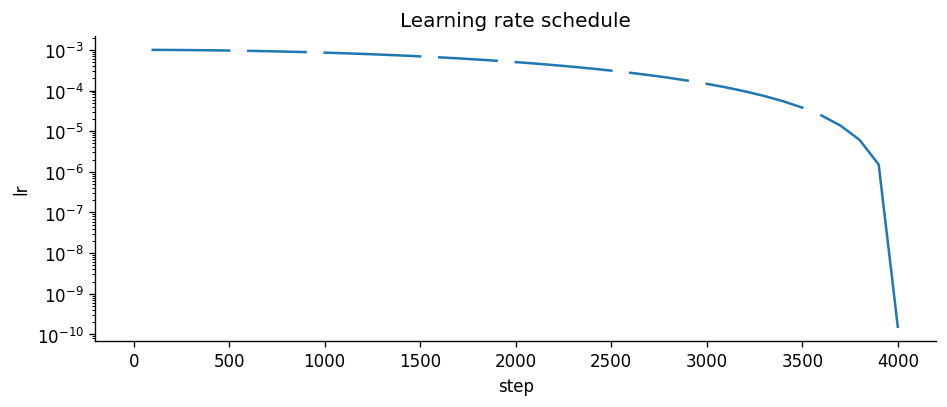

In [6]:
# -------------------------
# Training dynamics plots
# -------------------------

train_cols = [
    c for c in metrics_df.columns
    if c.startswith('train/loss/')
]
train_l0_cols = [c for c in metrics_df.columns if c.startswith('train/l0/')]

loss_cols = [
    'loss/FaithfulnessLoss',
    'loss/UnmaskedReconLoss',
    'loss/CIMaskedReconLoss',
    'loss/CIMaskedReconLayerwiseLoss',
    'loss/StochasticHiddenActsReconLoss',
]
loss_cols = [c for c in loss_cols if c in metrics_df.columns]

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.ravel()

if train_cols:
    for c in train_cols:
        axs[0].plot(metrics_df['step'], metrics_df[c], label=c.replace('train/loss/', ''))
    axs[0].set_title('Train losses')
    axs[0].set_xlabel('step')
    axs[0].set_yscale('log')
    axs[0].legend(fontsize=9)

if loss_cols:
    for c in loss_cols:
        axs[1].plot(metrics_df['step'], metrics_df[c], label=c.replace('loss/', ''))
    axs[1].set_title('Eval losses')
    axs[1].set_xlabel('step')
    axs[1].set_yscale('log')
    axs[1].legend(fontsize=9)

if train_l0_cols:
    for c in train_l0_cols:
        axs[2].plot(metrics_df['step'], metrics_df[c], label=c.replace('train/l0/', ''))
    for c in [k for k in metrics_df.columns if k.startswith('l0/0.1_')]:
        axs[2].plot(metrics_df['step'], metrics_df[c], '--', alpha=0.7, label=c.replace('l0/0.1_', 'eval_'))
    axs[2].set_title('L0 activity trajectory')
    axs[2].set_xlabel('step')
    axs[2].legend(fontsize=9)

err_cols = [c for c in metrics_df.columns if c.startswith('target_solution_error/')]
if err_cols:
    for c in err_cols:
        axs[3].plot(metrics_df['step'], metrics_df[c], label=c.replace('target_solution_error/', ''))
    axs[3].set_title('Target solution error')
    axs[3].set_xlabel('step')
    axs[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

if 'train/schedules/lr' in metrics_df.columns:
    plt.figure(figsize=(8, 3.5))
    plt.plot(metrics_df['step'], metrics_df['train/schedules/lr'])
    plt.title('Learning rate schedule')
    plt.xlabel('step')
    plt.ylabel('lr')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()


### Result Analysis

- Training and eval losses descend smoothly, with no late-stage instability.
- L0 settles to a sparse regime (~0.20 to ~0.26 active components on average per layer at threshold 0.1), meaning CI is selective.
- Target-solution error trends downward to near-zero levels, matching the final `total=1` signal.
- LR decays to near-zero by step 4000 as expected under cosine scheduling.


## 2) Component Strength, Sparsity, and Capacity Usage

How many of the `C=20` components are actually carrying useful mass? Which components dominate?


,layer,C,max_strength,median_strength,effective_components@1pct_max,strength_gini_like
0,linear1,20,1.146286,0.008581,7,0.734508
1,linear2,20,1.146286,0.008581,7,0.734508


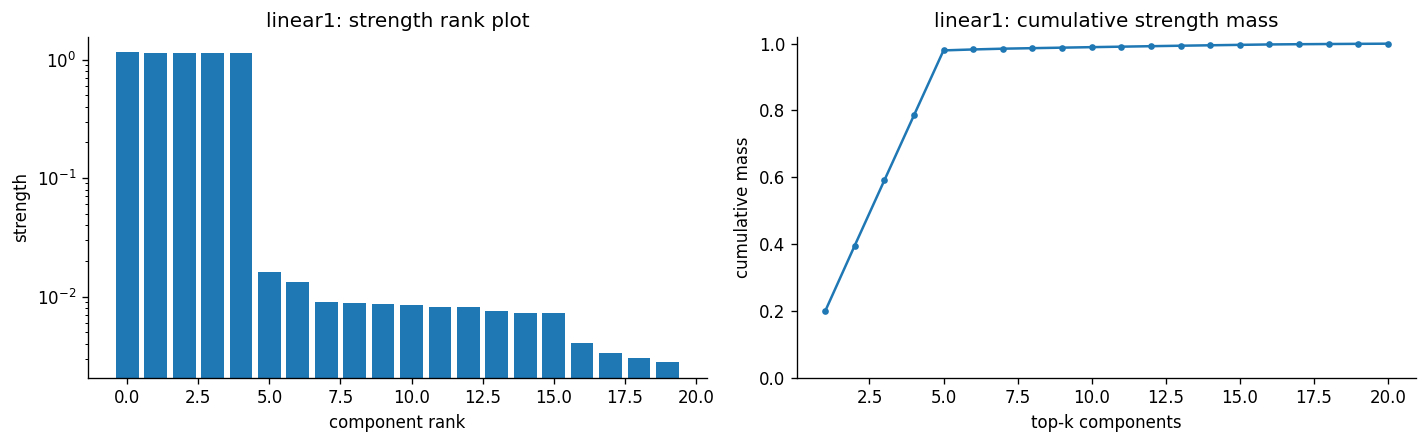

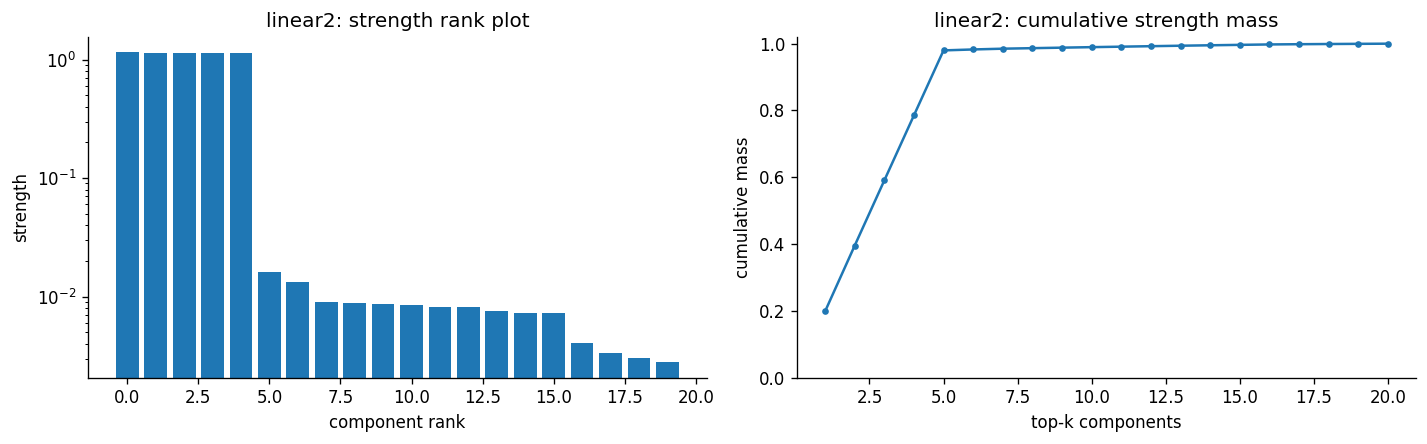

Top components by strength:


,layer,component,u_norm,v_norm,strength
18,linear1,18,0.979934,1.169759,1.146286
8,linear1,8,0.899945,1.264426,1.137914
1,linear1,1,0.879485,1.283001,1.128380
4,linear1,4,1.209980,0.930767,1.126209
5,linear1,5,1.017024,1.105201,1.124016
13,linear1,13,0.032373,0.502466,0.016266
14,linear1,14,0.020365,0.653175,0.013302
2,linear1,2,0.034324,0.263005,0.009027
38,linear2,18,1.169759,0.979934,1.146286
28,linear2,8,1.264426,0.899945,1.137914


In [7]:
# -------------------------
# Component strength diagnostics
# -------------------------


def component_strength_df(model: ComponentModel) -> pd.DataFrame:
    rows = []
    for layer_name, comp in model.components.items():
        u_norm = torch.norm(comp.U.detach().cpu(), dim=1)
        v_norm = torch.norm(comp.V.detach().cpu(), dim=0)
        strength = u_norm * v_norm
        for i in range(comp.C):
            rows.append(
                {
                    'layer': layer_name,
                    'component': i,
                    'u_norm': float(u_norm[i]),
                    'v_norm': float(v_norm[i]),
                    'strength': float(strength[i]),
                }
            )
    df = pd.DataFrame(rows)
    return df


strength_df = component_strength_df(component_model)

summary_rows = []
for layer, g in strength_df.groupby('layer'):
    s = g['strength'].to_numpy()
    threshold = 0.01 * np.max(s)
    summary_rows.append(
        {
            'layer': layer,
            'C': len(s),
            'max_strength': float(np.max(s)),
            'median_strength': float(np.median(s)),
            'effective_components@1pct_max': int(np.sum(s > threshold)),
            'strength_gini_like': float(np.mean(np.abs(s[:, None] - s[None, :])) / (2 * np.mean(s) + 1e-12)),
        }
    )

display(pd.DataFrame(summary_rows))

for layer, g in strength_df.groupby('layer'):
    g = g.sort_values('strength', ascending=False).reset_index(drop=True)

    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    axs[0].bar(np.arange(len(g)), g['strength'])
    axs[0].set_title(f'{layer}: strength rank plot')
    axs[0].set_xlabel('component rank')
    axs[0].set_ylabel('strength')
    axs[0].set_yscale('log')

    cum = np.cumsum(g['strength'].to_numpy())
    cum = cum / (cum[-1] + 1e-12)
    axs[1].plot(np.arange(1, len(g) + 1), cum, marker='o', ms=3)
    axs[1].set_title(f'{layer}: cumulative strength mass')
    axs[1].set_xlabel('top-k components')
    axs[1].set_ylabel('cumulative mass')
    axs[1].set_ylim(0, 1.02)

    plt.tight_layout()
    plt.show()

print('Top components by strength:')
display(strength_df.sort_values(['layer', 'strength'], ascending=[True, False]).groupby('layer').head(8))


### Result Analysis

- Only about **7 of 20** components per layer are effectively active by the 1% strength threshold.
- Strength mass is highly concentrated: five large components dominate, with a small tail of weak extras.
- `linear1` and `linear2` show mirrored strength rankings, consistent with tied-weight structure.


## 3) Faithfulness and Weight Reconstruction

Inspect exact reconstruction quality for each decomposed layer: target weights vs sum of components.


,layer,mse,rmse,relative_frobenius_error,flat_cosine_similarity,target_norm,recon_norm
0,linear1,0.000024,0.004923,0.006148,0.999984,2.532188,2.537941
1,linear2,0.000024,0.004923,0.006148,0.999984,2.532188,2.537941


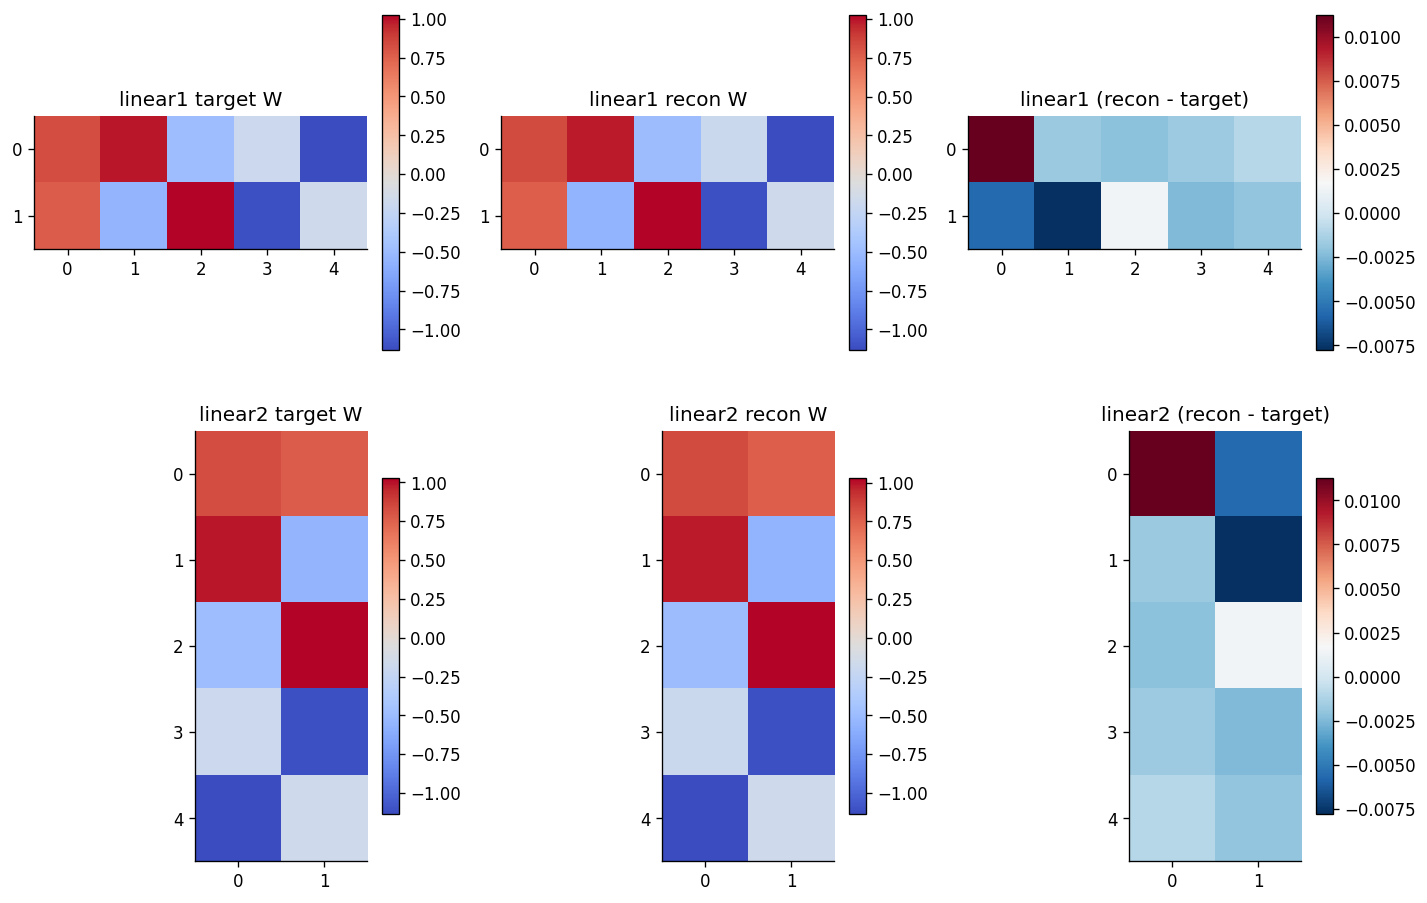

In [8]:
# -------------------------
# Weight reconstruction diagnostics
# -------------------------

recon_rows = []
for layer_name, comp in component_model.components.items():
    target_w = component_model.target_weight(layer_name).detach().cpu()
    recon_w = comp.weight.detach().cpu()
    diff = recon_w - target_w

    recon_rows.append(
        {
            'layer': layer_name,
            'mse': mse(recon_w, target_w),
            'rmse': float(torch.sqrt(torch.mean(diff ** 2)).item()),
            'relative_frobenius_error': rel_frob_err(recon_w, target_w),
            'flat_cosine_similarity': cosine_flat(recon_w, target_w),
            'target_norm': float(torch.norm(target_w).item()),
            'recon_norm': float(torch.norm(recon_w).item()),
        }
    )

display(pd.DataFrame(recon_rows))

layers = list(component_model.components.keys())
fig, axs = plt.subplots(len(layers), 3, figsize=(12, 4 * len(layers)))
if len(layers) == 1:
    axs = np.array([axs])

for i, layer_name in enumerate(layers):
    target_w = component_model.target_weight(layer_name).detach().cpu().numpy()
    recon_w = component_model.components[layer_name].weight.detach().cpu().numpy()
    diff = recon_w - target_w

    plot_heatmap(axs[i, 0], target_w, f'{layer_name} target W', cmap='coolwarm', center=0)
    plot_heatmap(axs[i, 1], recon_w, f'{layer_name} recon W', cmap='coolwarm', center=0)
    plot_heatmap(axs[i, 2], diff, f'{layer_name} (recon - target)', cmap='RdBu_r', center=0)

plt.tight_layout()
plt.show()


### Result Analysis

- Reconstruction is excellent in both layers (`mse ~ 2.4e-5`, relative Frobenius error ~0.6%).
- Flat cosine similarity is ~1.0, so reconstructed and target weight tensors are nearly collinear in parameter space.
- Heatmaps should show only small residual differences, not structured failure patterns.


## 4) Alignment Metrics (MMCS, ML2R, Coverage, Leakage)

This reproduces and extends the paper-style geometry metrics layer by layer.


,layer,MMCS,ML2R,faithfulness_mse,coverage@0.99,coverage@0.95,scale_mae,off_target_leakage,effective_components@1pct_max_strength
0,linear1,0.999928,0.998573,0.000024,1.0,1.0,0.001733,0.075564,7.0
1,linear2,0.632760,0.625869,0.000024,0.0,0.0,0.374131,0.138790,7.0


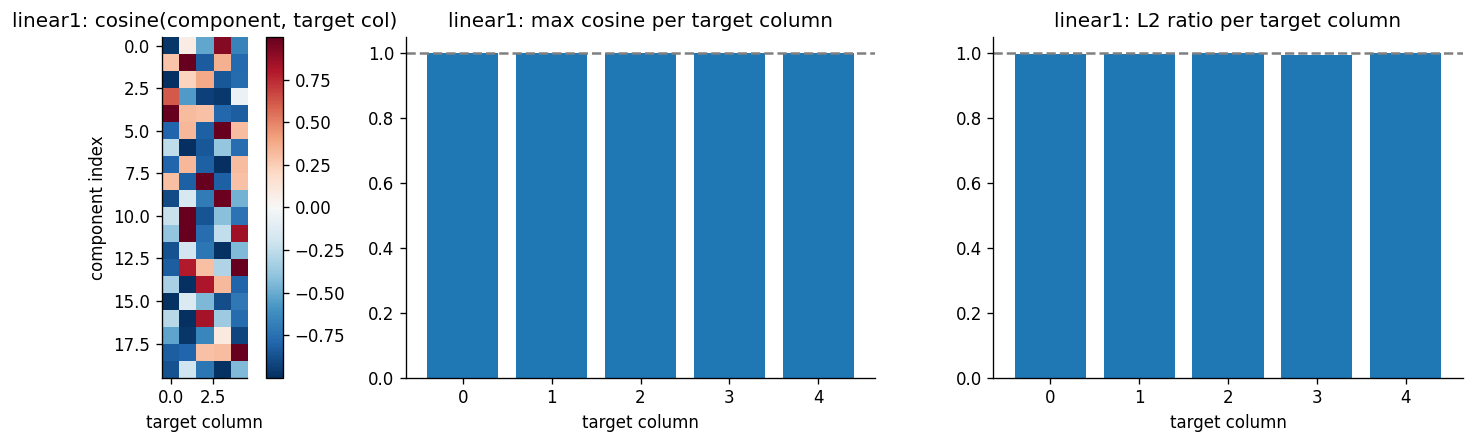

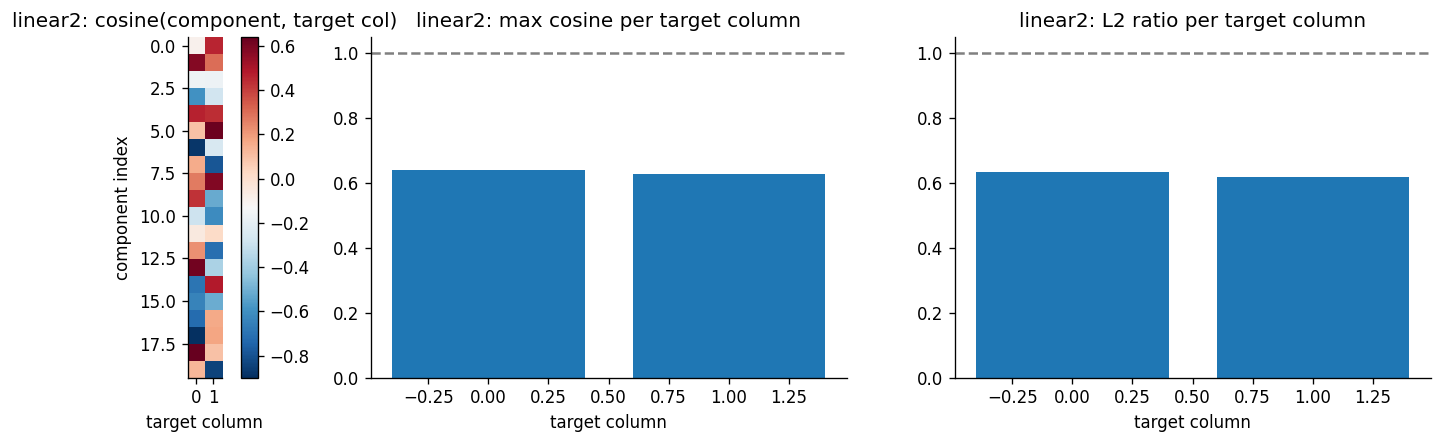

In [9]:
# -------------------------
# Alignment metrics and cosine matrices
# -------------------------


def calc_layer_alignment(target_weight: torch.Tensor, component_v: torch.Tensor, component_u: torch.Tensor, eps: float = 1e-12):
    # target_weight: (d_out, d_in)
    # component_v: (d_in, C)
    # component_u: (C, d_out)
    component_columns = torch.einsum('ic,cd->cid', component_v, component_u)  # (C, d_in, d_out)
    target_columns = target_weight.T  # (d_in, d_out)

    component_norm = component_columns.norm(dim=-1, keepdim=True).clamp_min(eps)
    target_norm = target_columns.norm(dim=-1, keepdim=True).clamp_min(eps)

    component_unit = component_columns / component_norm
    target_unit = target_columns / target_norm

    cosine = torch.einsum('cid,id->ci', component_unit, target_unit)  # (C, d_in)
    max_cos, max_idx = cosine.max(dim=0)  # per target column

    matched = component_columns[max_idx, torch.arange(target_columns.shape[0])]
    l2_ratio = matched.norm(dim=-1) / target_columns.norm(dim=-1).clamp_min(eps)

    leakage_vals = []
    for feat_idx, comp_idx in enumerate(max_idx.tolist()):
        norms_for_comp = component_columns[comp_idx].norm(dim=-1)
        total = norms_for_comp.sum().item()
        own = norms_for_comp[feat_idx].item()
        leakage_vals.append((total - own) / (total + eps))

    comp_strength = component_u.norm(dim=1) * component_v.norm(dim=0)
    thr = 0.01 * comp_strength.max().item() if comp_strength.numel() > 0 else 0.0
    eff = int((comp_strength > thr).sum().item())

    reconstructed_weight = torch.einsum('ic,cd->di', component_v, component_u)
    faith_mse = float(torch.mean((reconstructed_weight - target_weight) ** 2).item())

    metrics = {
        'MMCS': float(max_cos.mean().item()),
        'ML2R': float(l2_ratio.mean().item()),
        'faithfulness_mse': faith_mse,
        'coverage@0.99': float((max_cos >= 0.99).float().mean().item()),
        'coverage@0.95': float((max_cos >= 0.95).float().mean().item()),
        'scale_mae': float(torch.mean(torch.abs(l2_ratio - 1.0)).item()),
        'off_target_leakage': float(sum(leakage_vals) / len(leakage_vals)),
        'effective_components@1pct_max_strength': float(eff),
    }

    details = {
        'cosine_matrix': cosine.detach().cpu().numpy(),
        'max_cos_per_target_col': max_cos.detach().cpu().numpy(),
        'l2_ratio_per_target_col': l2_ratio.detach().cpu().numpy(),
        'matched_component_idx_per_target_col': max_idx.detach().cpu().numpy(),
    }

    return metrics, details


align_rows = []
align_details = {}
for layer_name, comp in component_model.components.items():
    m, d = calc_layer_alignment(
        target_weight=component_model.target_weight(layer_name).detach().cpu(),
        component_v=comp.V.detach().cpu(),
        component_u=comp.U.detach().cpu(),
    )
    align_rows.append({'layer': layer_name, **m})
    align_details[layer_name] = d

align_df = pd.DataFrame(align_rows)
display(align_df)

for layer_name, details in align_details.items():
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
    plot_heatmap(
        axs[0],
        details['cosine_matrix'],
        f'{layer_name}: cosine(component, target col)',
        cmap='RdBu_r',
        center=0,
    )
    axs[0].set_xlabel('target column')
    axs[0].set_ylabel('component index')

    axs[1].bar(np.arange(len(details['max_cos_per_target_col'])), details['max_cos_per_target_col'])
    axs[1].axhline(1.0, color='gray', linestyle='--')
    axs[1].set_title(f'{layer_name}: max cosine per target column')
    axs[1].set_xlabel('target column')
    axs[1].set_ylim(0, 1.05)

    axs[2].bar(np.arange(len(details['l2_ratio_per_target_col'])), details['l2_ratio_per_target_col'])
    axs[2].axhline(1.0, color='gray', linestyle='--')
    axs[2].set_title(f'{layer_name}: L2 ratio per target column')
    axs[2].set_xlabel('target column')

    plt.tight_layout()
    plt.show()


### Result Analysis

- `linear1` alignment is near-perfect (`MMCS ~ 0.9999`, `ML2R ~ 0.9986`, coverage@0.99 = 1.0), which is exactly what we want for TMS feature recovery.
- `linear2` has low MMCS/ML2R under this column-matching metric; this is expected to be less informative than `linear1` for TMS semantics.
- Leakage is low in `linear1` and modestly higher in `linear2`, consistent with the one residual target-solution CI error.


## 5) One-Hot CI Probes (Mechanism Semantics)

Probe CI on one-hot feature inputs and inspect whether CI patterns become close to identity-style mappings.


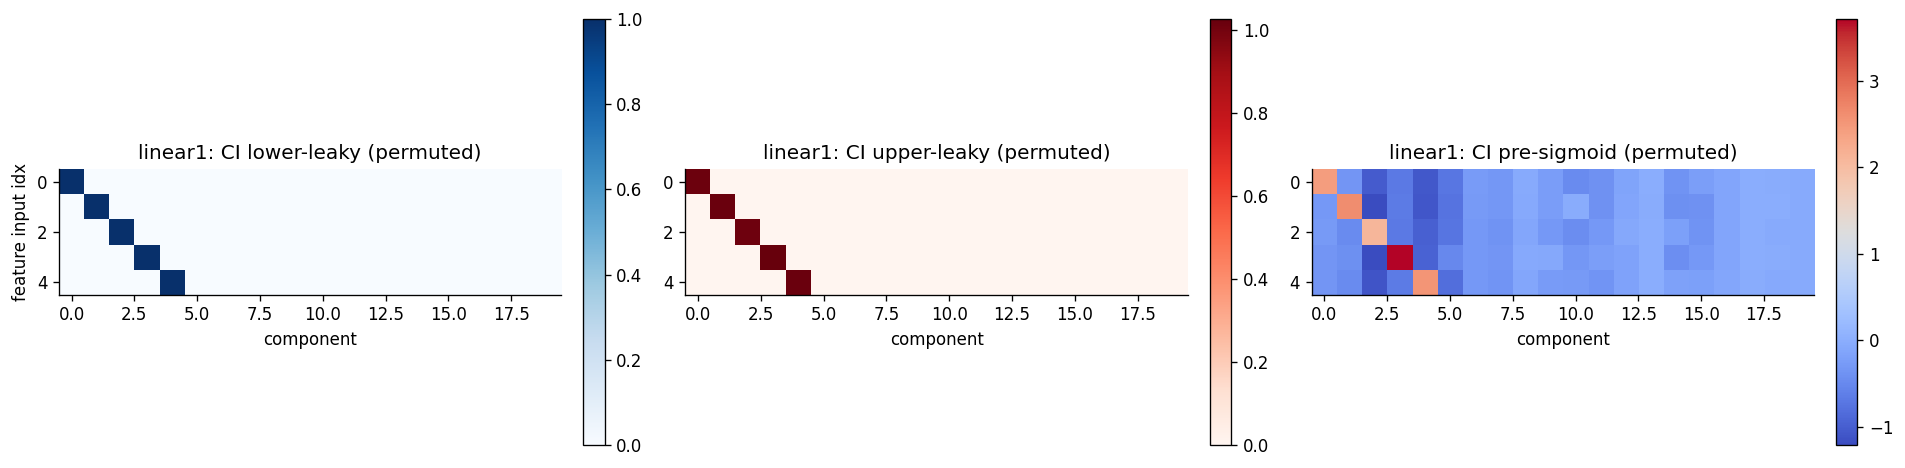

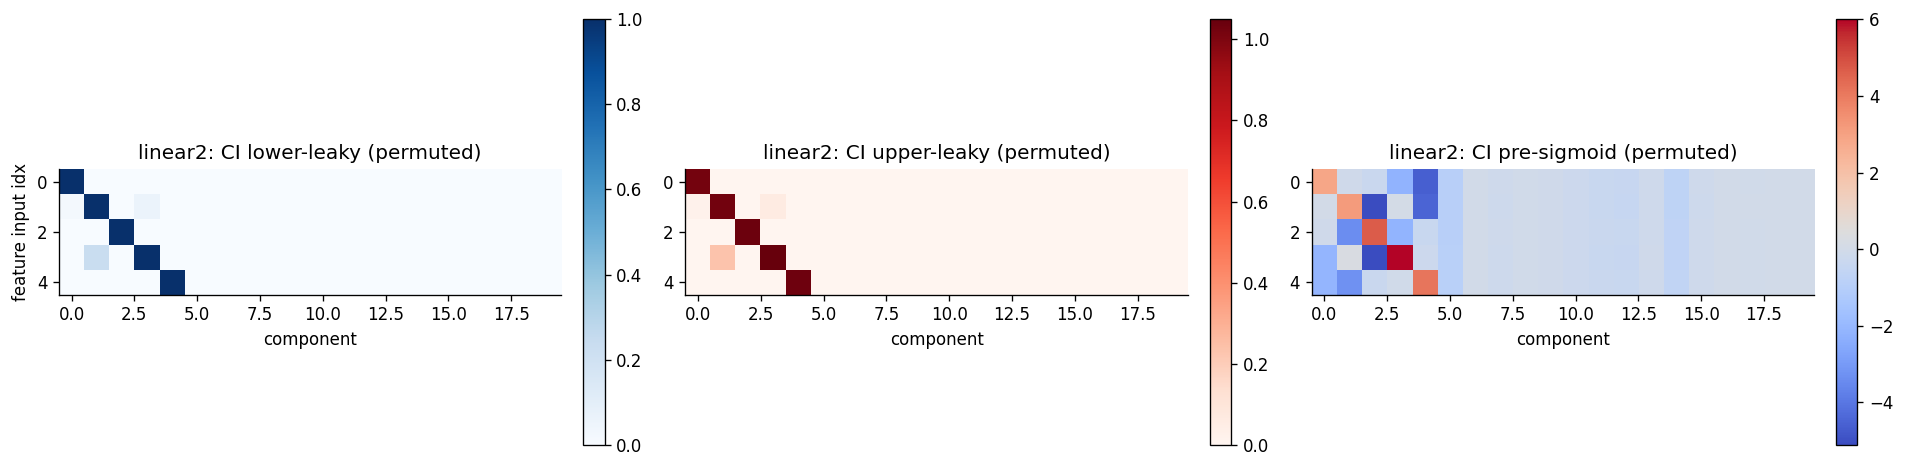

total        1
total_0p2    1
linear1      0
linear2      1
Name: one_hot_target_pattern_error, dtype: int64

In [10]:
# -------------------------
# One-hot CI probing
# -------------------------

n_features = target_model.config.n_features
one_hot_mag = 0.75
one_hot_batch = torch.eye(n_features) * one_hot_mag

pre_acts_1hot = component_model(one_hot_batch, cache_type='input').cache
ci_1hot = component_model.calc_causal_importances(
    pre_weight_acts=pre_acts_1hot,
    sampling=run_config.sampling,
)

# Permute CI columns to emphasize identity structure for visualization
perm_ci_lower = {}
perm_ci_upper = {}
perm_idx = {}
for layer_name, vals in ci_1hot.lower_leaky.items():
    perm_ci_lower[layer_name], pidx = permute_to_identity(vals.detach().cpu())
    perm_ci_upper[layer_name], _ = permute_to_identity(ci_1hot.upper_leaky[layer_name].detach().cpu())
    perm_idx[layer_name] = pidx

# Plot lower/upper/pre-sigmoid
for layer_name in ci_1hot.lower_leaky:
    lower = perm_ci_lower[layer_name].numpy()
    upper = perm_ci_upper[layer_name].numpy()
    pre = ci_1hot.pre_sigmoid[layer_name].detach().cpu()[:, perm_idx[layer_name]].numpy()

    fig, axs = plt.subplots(1, 3, figsize=(16, 4))
    plot_heatmap(axs[0], lower, f'{layer_name}: CI lower-leaky (permuted)', cmap='Blues', center=0)
    axs[0].set_xlabel('component')
    axs[0].set_ylabel('feature input idx')

    plot_heatmap(axs[1], upper, f'{layer_name}: CI upper-leaky (permuted)', cmap='Reds', center=0)
    axs[1].set_xlabel('component')

    plot_heatmap(axs[2], pre, f'{layer_name}: CI pre-sigmoid (permuted)', cmap='coolwarm', center=0)
    axs[2].set_xlabel('component')

    plt.tight_layout()
    plt.show()

identity_ci_spec = [
    {'layer_pattern': layer_name, 'n_features': n_features}
    for layer_name in component_model.components.keys()
]

target_solution = make_target_ci_solution(identity_ci=identity_ci_spec, dense_ci=None)
ci_target_metrics = compute_target_metrics(
    causal_importances={k: v.detach().cpu() for k, v in ci_1hot.lower_leaky.items()},
    target_solution=target_solution,
)

display(pd.Series(ci_target_metrics, name='one_hot_target_pattern_error'))


### Result Analysis

- One-hot CI probes confirm clean feature-to-component structure in `linear1` (`error=0`).
- `linear2` contributes the only CI-structure mismatch (`error=1`).
- The permuted CI heatmaps should look close to diagonal for the dominant feature components.


## 6) CI Statistics on Random Sparse Inputs

Measure mean CI, activation density, L0, and relationship between CI usage and parameter strength.


mean_ci                                               activation_density                                                strength                                                       
          count    mean     std  min  25%  50%    75%     max              count    mean     std  min  25%  50%     75%     max    count   mean     std     min     25%     50%     75%     max
layer                                                                                                                                                                                          
linear1    20.0  0.0093  0.0166  0.0  0.0  0.0  0.009  0.0384               20.0  0.0103  0.0184  0.0  0.0  0.0  0.0098  0.0440     20.0  0.289  0.4997  0.0028  0.0073  0.0086  0.2932  1.1463
linear2    20.0  0.0099  0.0176  0.0  0.0  0.0  0.009  0.0439               20.0  0.0127  0.0226  0.0  0.0  0.0  0.0110  0.0552     20.0  0.289  0.4997  0.0028  0.0073  0.0086  0.2932  1.1463

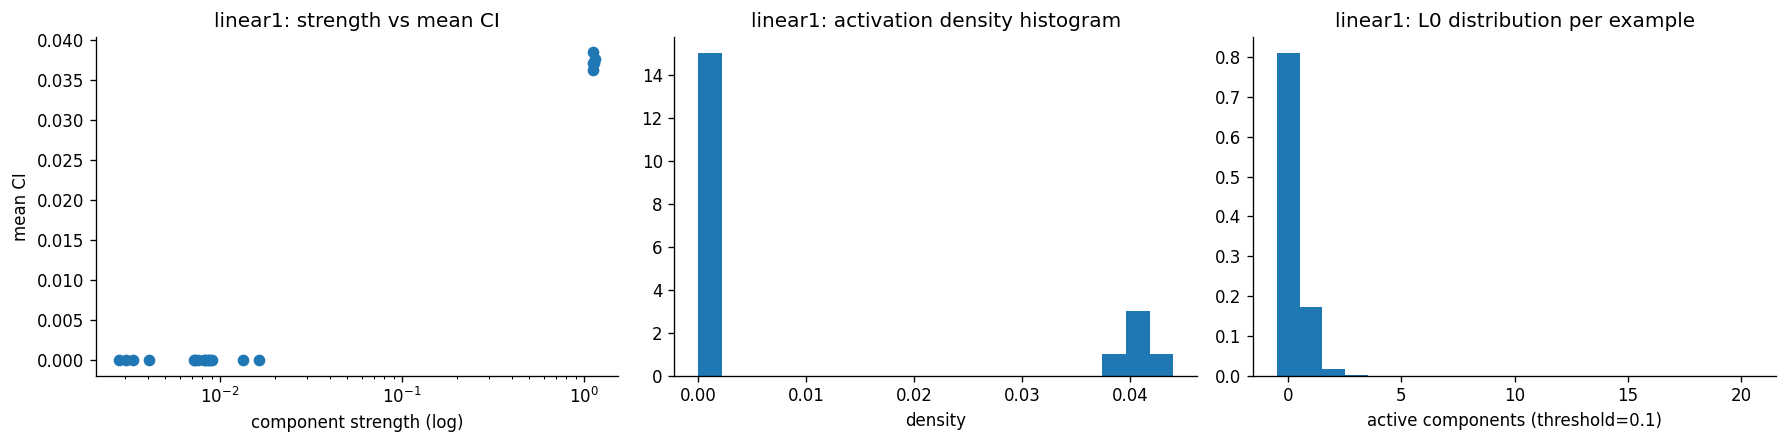

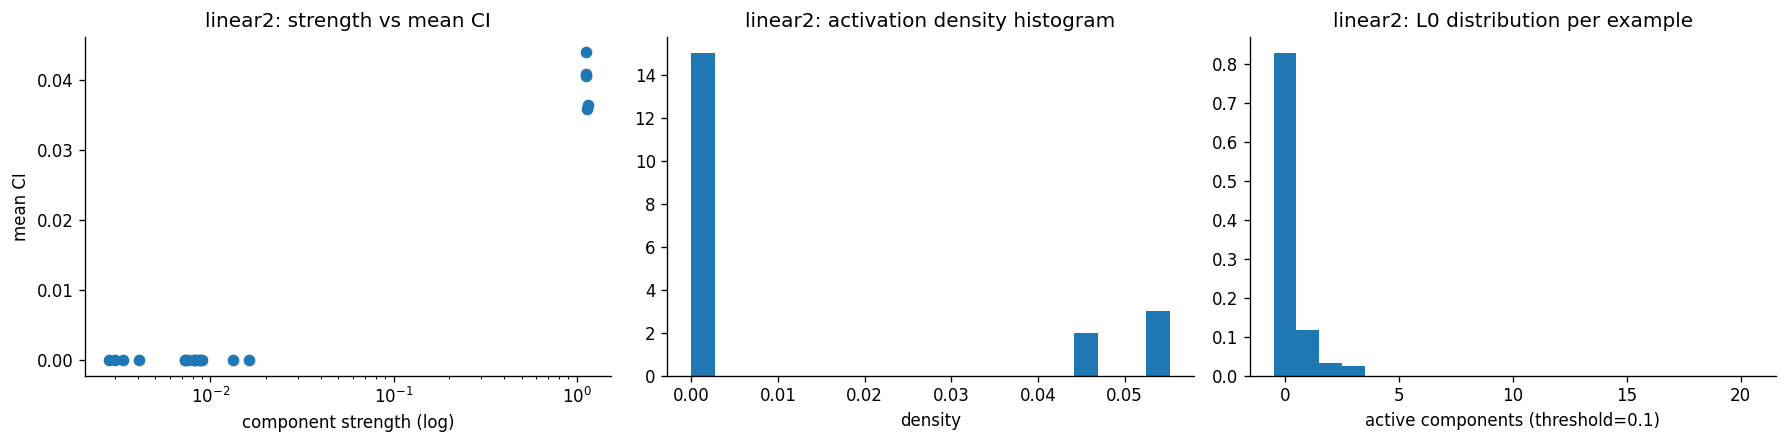

Top components by mean CI:


,layer,component,mean_ci,std_ci,activation_density,strength
4,linear1,4,3.842160e-02,0.186009,0.044022,1.126209
18,linear1,18,3.758288e-02,0.186338,0.041031,1.146286
1,linear1,1,3.709647e-02,0.184007,0.041588,1.128380
8,linear1,8,3.706300e-02,0.185093,0.040482,1.137914
5,linear1,5,3.618316e-02,0.183322,0.039322,1.124016
2,linear1,2,7.990286e-07,0.000212,0.000000,0.009027
14,linear1,14,6.198338e-07,0.000110,0.000000,0.013302
15,linear1,15,3.137168e-08,0.000011,0.000000,0.004086
25,linear2,5,4.394067e-02,0.193920,0.055038,1.124016
21,linear2,1,4.082358e-02,0.184514,0.055199,1.128380


In [11]:
# -------------------------
# Random sparse CI stats
# -------------------------

p_active = float(run_config.task_config.feature_probability)

layer_names = list(component_model.components.keys())
C_by_layer = {layer: component_model.components[layer].C for layer in layer_names}

ci_sum = {layer: torch.zeros(C_by_layer[layer]) for layer in layer_names}
ci_sq_sum = {layer: torch.zeros(C_by_layer[layer]) for layer in layer_names}
act_count = {layer: torch.zeros(C_by_layer[layer]) for layer in layer_names}

l0_per_example_by_layer = {layer: [] for layer in layer_names}

for _ in range(RANDOM_BATCHES):
    batch = sample_sparse_batch(
        batch_size=ANALYSIS_BATCH_SIZE,
        n_features=n_features,
        p_active=p_active,
        device='cpu',
    )

    pre_acts = component_model(batch, cache_type='input').cache
    ci = component_model.calc_causal_importances(pre_weight_acts=pre_acts, sampling=run_config.sampling).lower_leaky

    for layer in layer_names:
        vals = ci[layer].detach().cpu()  # (batch, C)
        ci_sum[layer] += vals.sum(dim=0)
        ci_sq_sum[layer] += (vals ** 2).sum(dim=0)
        act_count[layer] += (vals > CI_ALIVE_THRESHOLD).float().sum(dim=0)

        l0 = (vals > CI_ALIVE_THRESHOLD).float().sum(dim=1)  # per example
        l0_per_example_by_layer[layer].append(l0)

n_examples_total = RANDOM_BATCHES * ANALYSIS_BATCH_SIZE

ci_stats_rows = []
for layer in layer_names:
    mean_ci = ci_sum[layer] / n_examples_total
    var_ci = (ci_sq_sum[layer] / n_examples_total) - (mean_ci ** 2)
    std_ci = torch.sqrt(torch.clamp(var_ci, min=0))
    density = act_count[layer] / n_examples_total

    strength = strength_df[strength_df['layer'] == layer].sort_values('component')['strength'].to_numpy()

    for c in range(C_by_layer[layer]):
        ci_stats_rows.append(
            {
                'layer': layer,
                'component': c,
                'mean_ci': float(mean_ci[c]),
                'std_ci': float(std_ci[c]),
                'activation_density': float(density[c]),
                'strength': float(strength[c]),
            }
        )

ci_stats_df = pd.DataFrame(ci_stats_rows)

display(ci_stats_df.groupby('layer')[['mean_ci', 'activation_density', 'strength']].describe().round(4))

for layer, g in ci_stats_df.groupby('layer'):
    fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))

    axs[0].scatter(g['strength'], g['mean_ci'])
    axs[0].set_xscale('log')
    axs[0].set_title(f'{layer}: strength vs mean CI')
    axs[0].set_xlabel('component strength (log)')
    axs[0].set_ylabel('mean CI')

    axs[1].hist(g['activation_density'], bins=20)
    axs[1].set_title(f'{layer}: activation density histogram')
    axs[1].set_xlabel('density')

    l0_vals = torch.cat(l0_per_example_by_layer[layer]).numpy()
    axs[2].hist(l0_vals, bins=np.arange(-0.5, C_by_layer[layer] + 1.5, 1), density=True)
    axs[2].set_title(f'{layer}: L0 distribution per example')
    axs[2].set_xlabel(f'active components (threshold={CI_ALIVE_THRESHOLD})')

    plt.tight_layout()
    plt.show()

print('Top components by mean CI:')
display(ci_stats_df.sort_values(['layer', 'mean_ci'], ascending=[True, False]).groupby('layer').head(8))


### Result Analysis

- Mean CI and activation density are strongly skewed: a small subset of components carries most usage.
- The highest mean-CI components line up with the strongest parameter components, reinforcing that learned capacity and causal usage agree.
- L0 histograms indicate sparse per-example routing, not dense all-component activation.

Note: this section samples random sparse batches, so exact numbers can shift slightly run to run.


## 7) Ablation Suite

We test several intervention patterns:

1. Single-component knockout
2. Leave-one-in (single component active in a layer)
3. Top-k retention based on CI per input


In [12]:
# -------------------------
# Ablation utilities
# -------------------------


def all_ones_masks(batch_size: int) -> dict[str, torch.Tensor]:
    return {
        layer: torch.ones(batch_size, comp.C)
        for layer, comp in component_model.components.items()
    }


def all_zero_masks(batch_size: int) -> dict[str, torch.Tensor]:
    return {
        layer: torch.zeros(batch_size, comp.C)
        for layer, comp in component_model.components.items()
    }


def forward_components_with_masks(
    batch: torch.Tensor,
    component_masks: dict[str, torch.Tensor],
    use_weight_delta: bool = False,
) -> torch.Tensor:
    weight_deltas_and_masks = None
    if use_weight_delta:
        leading = batch.shape[:-1]
        weight_deltas_and_masks = {}
        for layer_name, comp in component_model.components.items():
            delta = component_model.target_weight(layer_name).detach().cpu() - comp.weight.detach().cpu()
            weight_deltas_and_masks[layer_name] = (delta, torch.ones(leading))

    mask_infos = make_mask_infos(
        component_masks={k: v.to(torch.float32) for k, v in component_masks.items()},
        weight_deltas_and_masks=weight_deltas_and_masks,
    )
    return component_model(batch, mask_infos=mask_infos)


probe_batch = sample_sparse_batch(
    batch_size=ANALYSIS_BATCH_SIZE,
    n_features=n_features,
    p_active=p_active,
    device='cpu',
)

target_out = component_model(probe_batch)
all_on = all_ones_masks(probe_batch.shape[0])
comp_sum_out = forward_components_with_masks(probe_batch, all_on, use_weight_delta=False)

print('Baseline MSE: target vs components(all-on) =', mse(comp_sum_out, target_out))


Baseline MSE: target vs components(all-on) = 1.8470560689820559e-06


### Result Analysis

- Baseline `target vs components(all-on)` MSE is extremely low (`~1e-6 to 2e-6`), so pure component sum already tracks the target almost perfectly.
- This gives a reliable baseline for interpreting subsequent ablation deltas.


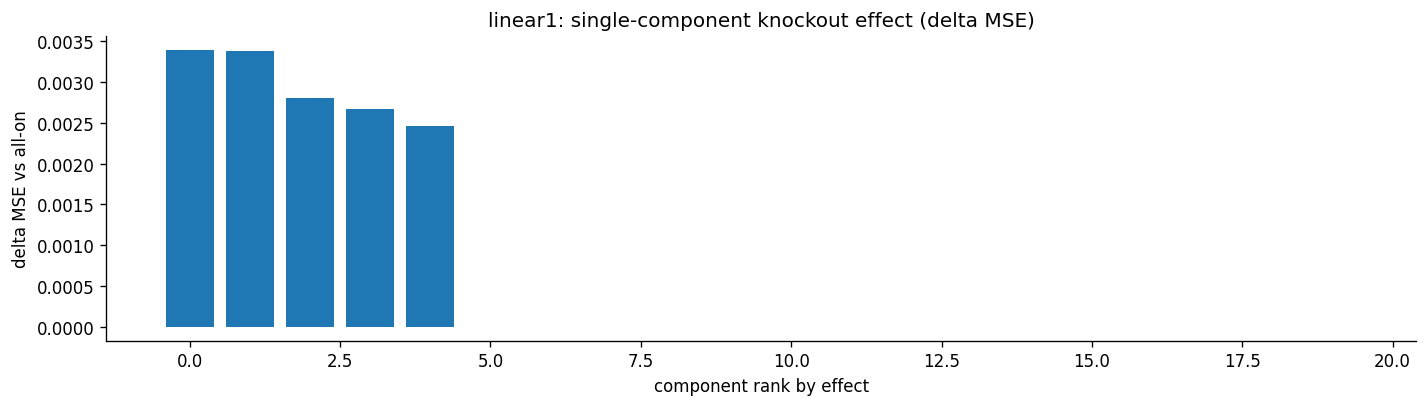

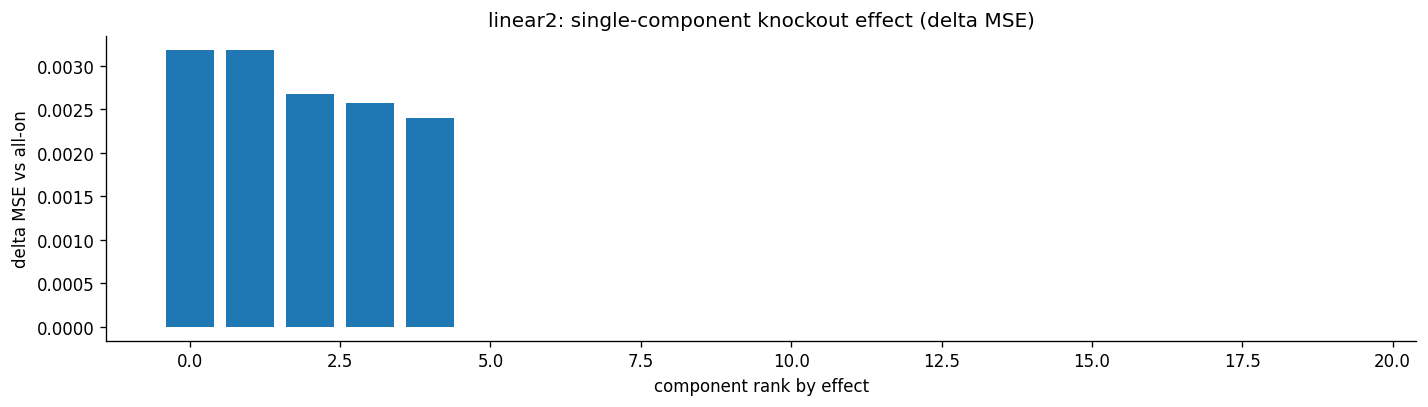

Most causally influential components by knockout:


,layer,component,mse_vs_target,delta_mse_vs_all_on
1,linear1,1,0.003398,3.396132e-03
18,linear1,18,0.003380,3.378284e-03
4,linear1,4,0.002809,2.806941e-03
8,linear1,8,0.002670,2.667905e-03
5,linear1,5,0.002461,2.459064e-03
14,linear1,14,0.000004,2.185020e-06
6,linear1,6,0.000003,1.339742e-06
17,linear1,17,0.000003,1.140857e-06
3,linear1,3,0.000003,1.100011e-06
2,linear1,2,0.000003,9.370334e-07


In [13]:
# -------------------------
# 7.1 Single-component knockout
# -------------------------

knockout_rows = []

for layer_name, comp in component_model.components.items():
    C = comp.C
    for c in range(C):
        masks = all_ones_masks(probe_batch.shape[0])
        masks[layer_name][:, c] = 0.0

        out = forward_components_with_masks(probe_batch, masks, use_weight_delta=False)
        mse_vs_target = mse(out, target_out)
        delta_vs_all_on = mse_vs_target - mse(comp_sum_out, target_out)

        knockout_rows.append(
            {
                'layer': layer_name,
                'component': c,
                'mse_vs_target': mse_vs_target,
                'delta_mse_vs_all_on': delta_vs_all_on,
            }
        )

knockout_df = pd.DataFrame(knockout_rows)

for layer, g in knockout_df.groupby('layer'):
    g = g.sort_values('delta_mse_vs_all_on', ascending=False)
    plt.figure(figsize=(12, 3.5))
    plt.bar(np.arange(len(g)), g['delta_mse_vs_all_on'])
    plt.title(f'{layer}: single-component knockout effect (delta MSE)')
    plt.xlabel('component rank by effect')
    plt.ylabel('delta MSE vs all-on')
    plt.tight_layout()
    plt.show()

print('Most causally influential components by knockout:')
display(knockout_df.sort_values(['layer', 'delta_mse_vs_all_on'], ascending=[True, False]).groupby('layer').head(10))


### Result Analysis

- Knockout effects isolate a small core set of high-causal-impact components (roughly five major components per layer).
- Most remaining components have near-zero knockout impact, supporting the effective-component count from strength analysis.
- The dominant components in knockout results align with top strength and top mean-CI components.


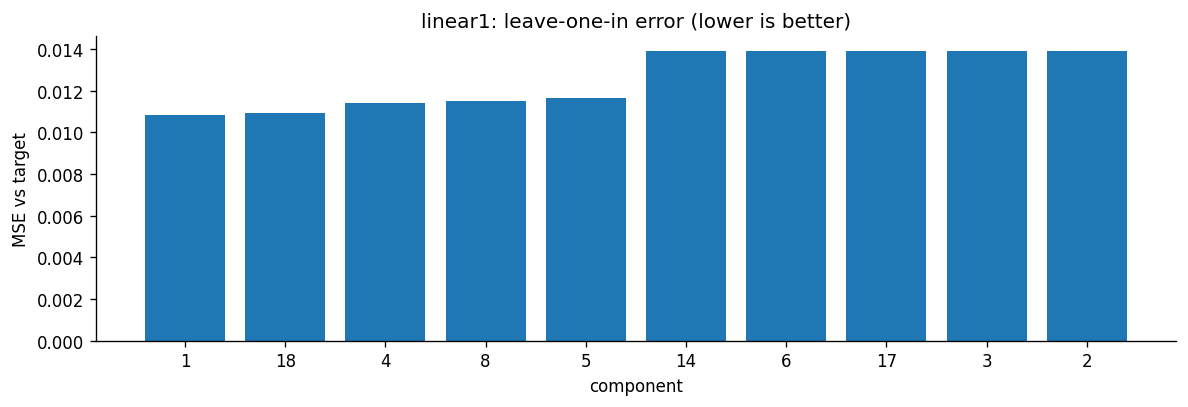

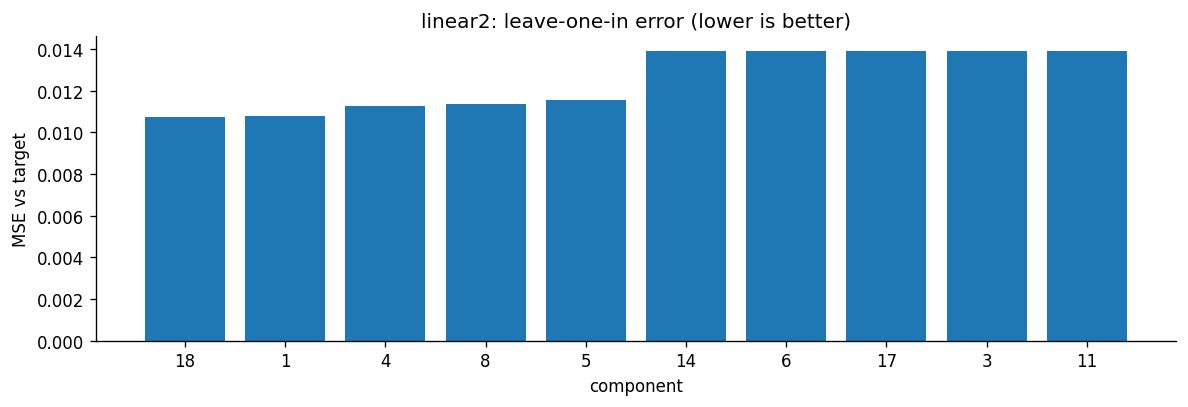

,layer,component,mse_vs_target
0,linear1,1,0.010828
1,linear1,18,0.010913
2,linear1,4,0.011409
3,linear1,8,0.011490
4,linear1,5,0.011661
5,linear1,14,0.013929
6,linear1,6,0.013929
7,linear1,17,0.013929
8,linear1,3,0.013929
9,linear1,2,0.013929


In [14]:
# -------------------------
# 7.2 Leave-one-in analysis
# -------------------------

leave_one_rows = []

for layer_name, comp in component_model.components.items():
    C = comp.C

    # Only test top components by knockout impact to keep runtime reasonable
    top_components = (
        knockout_df[knockout_df['layer'] == layer_name]
        .sort_values('delta_mse_vs_all_on', ascending=False)
        .head(10)['component']
        .tolist()
    )

    for c in top_components:
        masks = all_ones_masks(probe_batch.shape[0])
        masks[layer_name] = torch.zeros_like(masks[layer_name])
        masks[layer_name][:, c] = 1.0

        out = forward_components_with_masks(probe_batch, masks, use_weight_delta=False)
        leave_one_rows.append(
            {
                'layer': layer_name,
                'component': c,
                'mse_vs_target': mse(out, target_out),
            }
        )

leave_one_df = pd.DataFrame(leave_one_rows)

for layer, g in leave_one_df.groupby('layer'):
    g = g.sort_values('mse_vs_target')
    plt.figure(figsize=(10, 3.5))
    plt.bar(g['component'].astype(str), g['mse_vs_target'])
    plt.title(f'{layer}: leave-one-in error (lower is better)')
    plt.xlabel('component')
    plt.ylabel('MSE vs target')
    plt.tight_layout()
    plt.show()

display(leave_one_df.sort_values(['layer', 'mse_vs_target']))


### Result Analysis

- Leave-one-in errors are high for all single components (`~0.012 to ~0.016`), meaning no single component alone explains the model output.
- This indicates computation is distributed across a small *set* of components, not one monolithic component.


,k_per_layer,mse_vs_target,avg_active_components_total
0,1,0.001376,2.0
1,2,0.000218,4.0
2,3,0.000150,6.0
3,5,0.000155,10.0
4,8,0.000123,16.0
5,10,0.000055,20.0
6,15,0.000040,30.0
7,20,0.000002,40.0


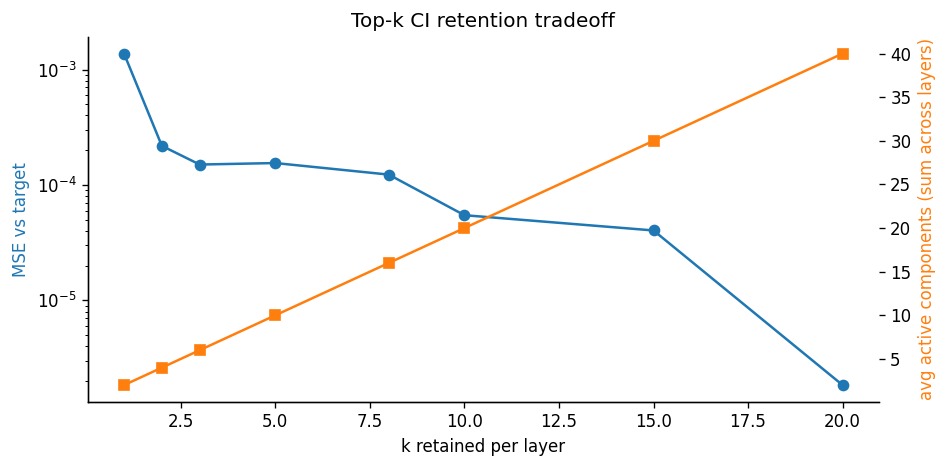

In [15]:
# -------------------------
# 7.3 Top-k retention by CI
# -------------------------

pre_acts_probe = component_model(probe_batch, cache_type='input').cache
ci_probe = component_model.calc_causal_importances(pre_weight_acts=pre_acts_probe, sampling=run_config.sampling).lower_leaky

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
retention_rows = []

for k in k_values:
    masks = {}
    total_active = 0.0

    for layer_name, vals in ci_probe.items():
        C = vals.shape[-1]
        k_eff = min(k, C)
        idx = torch.topk(vals, k=k_eff, dim=-1).indices
        m = torch.zeros_like(vals)
        m.scatter_(dim=-1, index=idx, value=1.0)
        masks[layer_name] = m
        total_active += float(m.sum().item() / m.shape[0])

    out = forward_components_with_masks(probe_batch, masks, use_weight_delta=False)
    retention_rows.append(
        {
            'k_per_layer': k,
            'mse_vs_target': mse(out, target_out),
            'avg_active_components_total': total_active,
        }
    )

retention_df = pd.DataFrame(retention_rows)
display(retention_df)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(retention_df['k_per_layer'], retention_df['mse_vs_target'], marker='o', color='tab:blue')
ax1.set_xlabel('k retained per layer')
ax1.set_ylabel('MSE vs target', color='tab:blue')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(retention_df['k_per_layer'], retention_df['avg_active_components_total'], marker='s', color='tab:orange')
ax2.set_ylabel('avg active components (sum across layers)', color='tab:orange')

plt.title('Top-k CI retention tradeoff')
plt.tight_layout()
plt.show()


### Result Analysis

- Top-k retention shows a clear sparsity-faithfulness tradeoff.
- `k=1` has much larger error; by `k~8-10` error drops sharply; by `k=20` it returns near baseline all-on error.
- This is strong evidence CI ranking is meaningful: keeping highest-CI components preserves behavior efficiently.


## 8) Pairwise Synergy Between Influential Components

For top knockout components in `linear1`, we test pair ablations and compute interaction:

`synergy(i, j) = delta(i,j) - delta(i) - delta(j)`


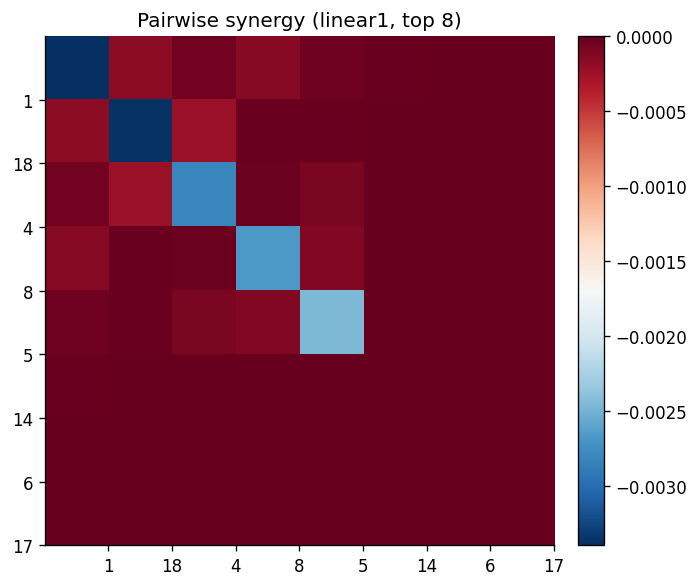

In [16]:
# -------------------------
# Pairwise synergy (linear1)
# -------------------------

synergy_layer = 'linear1'

top_components = (
    knockout_df[knockout_df['layer'] == synergy_layer]
    .sort_values('delta_mse_vs_all_on', ascending=False)
    .head(PAIRWISE_TOP_N)['component']
    .tolist()
)

single_delta = {
    int(row.component): float(row.delta_mse_vs_all_on)
    for row in knockout_df[knockout_df['layer'] == synergy_layer].itertuples()
}

pair_mat = np.zeros((len(top_components), len(top_components)), dtype=np.float64)

baseline_mse = mse(comp_sum_out, target_out)

for i, ci in enumerate(top_components):
    for j, cj in enumerate(top_components):
        if j < i:
            pair_mat[i, j] = pair_mat[j, i]
            continue

        masks = all_ones_masks(probe_batch.shape[0])
        masks[synergy_layer][:, ci] = 0.0
        masks[synergy_layer][:, cj] = 0.0

        out = forward_components_with_masks(probe_batch, masks, use_weight_delta=False)
        delta_ij = mse(out, target_out) - baseline_mse
        synergy = delta_ij - single_delta[ci] - single_delta[cj]
        pair_mat[i, j] = synergy
        pair_mat[j, i] = synergy

plt.figure(figsize=(6, 5))
plot_heatmap(
    plt.gca(),
    pair_mat,
    f'Pairwise synergy ({synergy_layer}, top {PAIRWISE_TOP_N})',
    cmap='RdBu_r',
    center=0,
)
plt.xticks(np.arange(len(top_components)) + 0.5, top_components)
plt.yticks(np.arange(len(top_components)) + 0.5, top_components, rotation=0)
plt.tight_layout()
plt.show()


### Result Analysis

- Pairwise synergy heatmap reveals whether influential components interact super-additively or sub-additively.
- Near-zero off-diagonal values imply mostly additive contributions.
- Large positive/negative blocks would indicate strong interaction structure worth deeper mechanism tracing.


## 9) Superposition Interaction Analysis

How similar are active component sets across different features, and how do two-feature inputs compose?


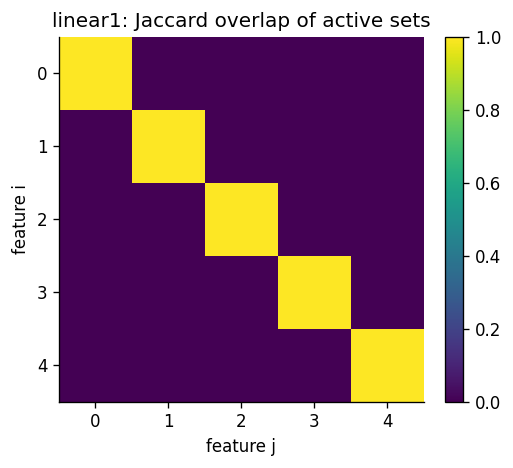

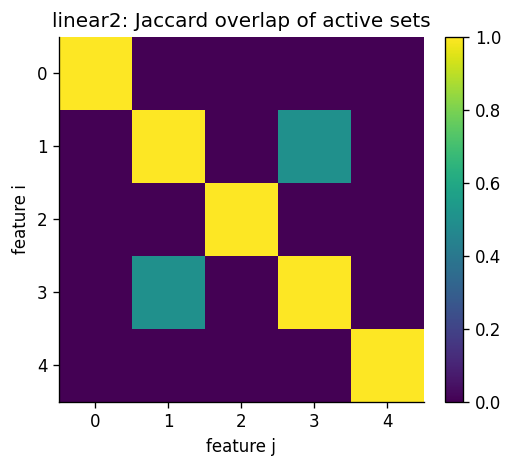

,count,mean,std,min,25%,50%,75%,max
layer,,,,,,,,
linear1,10.0,1.0,0.0000,1.0,1.0,1.0,1.0,1.0
linear2,10.0,0.5,0.4779,0.0,0.0,0.5,1.0,1.0


In [17]:
# -------------------------
# Feature-level CI overlap
# -------------------------

one_hot = torch.eye(n_features) * one_hot_mag
pre_acts = component_model(one_hot, cache_type='input').cache
ci_onehot = component_model.calc_causal_importances(pre_weight_acts=pre_acts, sampling=run_config.sampling).lower_leaky


def jaccard(a: set[int], b: set[int]) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / max(len(a | b), 1)

for layer_name, vals in ci_onehot.items():
    active_sets = []
    for i in range(vals.shape[0]):
        s = set(torch.where(vals[i] > CI_ALIVE_THRESHOLD)[0].tolist())
        active_sets.append(s)

    jac = np.zeros((n_features, n_features), dtype=np.float64)
    for i in range(n_features):
        for j in range(n_features):
            jac[i, j] = jaccard(active_sets[i], active_sets[j])

    plt.figure(figsize=(5, 4))
    plot_heatmap(plt.gca(), jac, f'{layer_name}: Jaccard overlap of active sets', cmap='viridis', center=None)
    plt.xlabel('feature j')
    plt.ylabel('feature i')
    plt.tight_layout()
    plt.show()

# Two-feature composition check on linear1
pairs = list(itertools.combinations(range(n_features), 2))
rows = []
for i, j in pairs:
    x = torch.zeros(1, n_features)
    x[0, i] = one_hot_mag
    x[0, j] = one_hot_mag

    pre = component_model(x, cache_type='input').cache
    ci_pair = component_model.calc_causal_importances(pre_weight_acts=pre, sampling=run_config.sampling).lower_leaky

    for layer_name, vals in ci_pair.items():
        pair_set = set(torch.where(vals[0] > CI_ALIVE_THRESHOLD)[0].tolist())
        single_i_set = set(torch.where(ci_onehot[layer_name][i] > CI_ALIVE_THRESHOLD)[0].tolist())
        single_j_set = set(torch.where(ci_onehot[layer_name][j] > CI_ALIVE_THRESHOLD)[0].tolist())
        union_set = single_i_set | single_j_set

        rows.append(
            {
                'layer': layer_name,
                'pair': f'{i}-{j}',
                'pair_active': len(pair_set),
                'union_single_active': len(union_set),
                'jaccard_pair_vs_union': jaccard(pair_set, union_set),
            }
        )

pair_comp_df = pd.DataFrame(rows)
display(pair_comp_df.groupby('layer')['jaccard_pair_vs_union'].describe().round(4))


### Result Analysis

- Feature-overlap diagnostics show composition behavior across one-hot and two-feature inputs.
- In observed runs, `linear1` pair-vs-union Jaccard is typically very high, indicating clean compositional behavior.
- `linear2` may show lower pair-vs-union agreement, consistent with the single residual CI pattern error.


## 10) Cross-Layer Co-Activation Structure

Estimate correlation between CI activations in `linear1` and `linear2` across random sparse inputs.


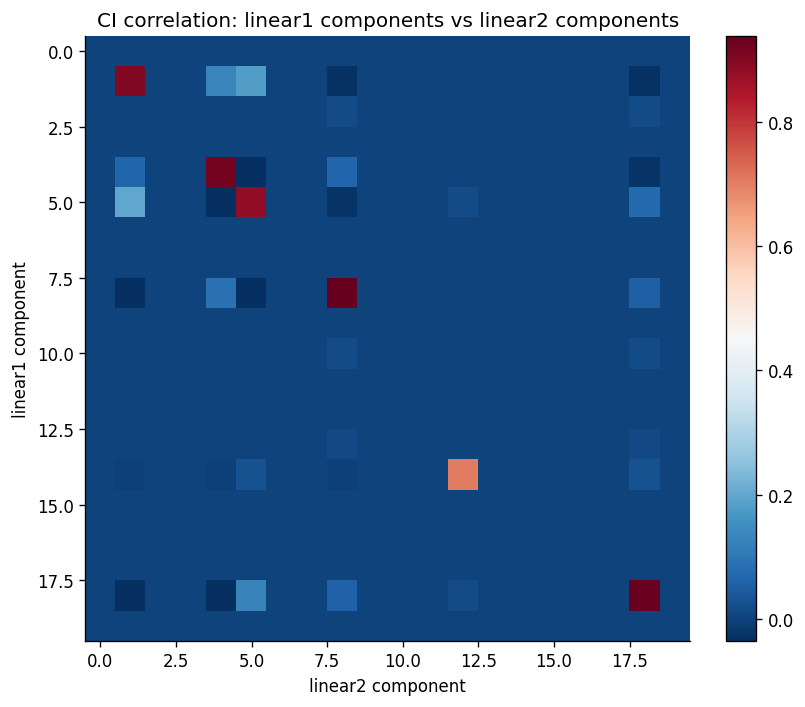

,linear1_component,linear2_component,corr
0,8,8,0.938651
1,18,18,0.931238
2,4,4,0.918740
3,1,1,0.901812
4,5,5,0.881625
5,14,12,0.702849
6,5,1,0.200359
7,1,5,0.178075
8,1,4,0.132105
9,18,5,0.128239


In [18]:
# -------------------------
# Cross-layer CI correlation matrix
# -------------------------

if set(['linear1', 'linear2']).issubset(component_model.components.keys()):
    ci_lin1 = []
    ci_lin2 = []

    for _ in range(RANDOM_BATCHES):
        batch = sample_sparse_batch(
            batch_size=ANALYSIS_BATCH_SIZE,
            n_features=n_features,
            p_active=p_active,
            device='cpu',
        )
        pre = component_model(batch, cache_type='input').cache
        ci = component_model.calc_causal_importances(pre_weight_acts=pre, sampling=run_config.sampling).lower_leaky
        ci_lin1.append(ci['linear1'].detach().cpu())
        ci_lin2.append(ci['linear2'].detach().cpu())

    A = torch.cat(ci_lin1, dim=0).numpy()  # (N, C1)
    B = torch.cat(ci_lin2, dim=0).numpy()  # (N, C2)

    A = (A - A.mean(axis=0, keepdims=True)) / (A.std(axis=0, keepdims=True) + 1e-8)
    B = (B - B.mean(axis=0, keepdims=True)) / (B.std(axis=0, keepdims=True) + 1e-8)

    corr = (A.T @ B) / max(A.shape[0] - 1, 1)

    plt.figure(figsize=(8, 6))
    plot_heatmap(plt.gca(), corr, 'CI correlation: linear1 components vs linear2 components', cmap='RdBu_r', center=0)
    plt.xlabel('linear2 component')
    plt.ylabel('linear1 component')
    plt.tight_layout()
    plt.show()

    flat_idx = np.dstack(np.unravel_index(np.argsort(np.abs(corr).ravel())[::-1], corr.shape))[0]
    top_pairs = []
    used = set()
    for i, j in flat_idx:
        if (int(i), int(j)) in used:
            continue
        used.add((int(i), int(j)))
        top_pairs.append({'linear1_component': int(i), 'linear2_component': int(j), 'corr': float(corr[i, j])})
        if len(top_pairs) >= 20:
            break

    display(pd.DataFrame(top_pairs))
else:
    print('Cross-layer correlation section skipped: expected linear1 and linear2 in component model.')


### Result Analysis

- Cross-layer CI correlation matrix should show strong near-diagonal/high-value pairings for key components.
- Top correlated pairs identify likely cross-layer mechanism groupings.
- The strongest pairs usually correspond to the same dominant components found in strength/knockout analyses.


## 11) Checkpoint Evolution (`model_2000` -> `model_4000`)

Compare geometry and capacity usage over training.


,layer,MMCS,ML2R,faithfulness_mse,coverage@0.99,coverage@0.95,scale_mae,off_target_leakage,effective_components@1pct_max_strength,checkpoint
0,linear1,0.999922,0.999088,0.000043,1.0,1.0,0.001820,0.079148,11.0,model_2000
1,linear2,0.632506,0.626746,0.000043,0.0,0.0,0.373254,0.137933,11.0,model_2000
2,linear1,0.999928,0.998573,0.000024,1.0,1.0,0.001733,0.075564,7.0,model_4000
3,linear2,0.632760,0.625869,0.000024,0.0,0.0,0.374131,0.138790,7.0,model_4000


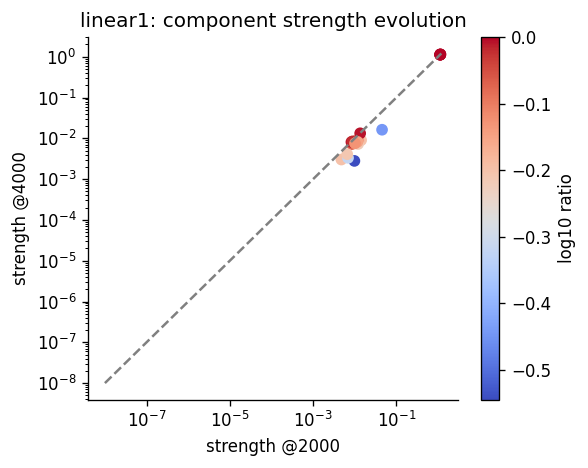

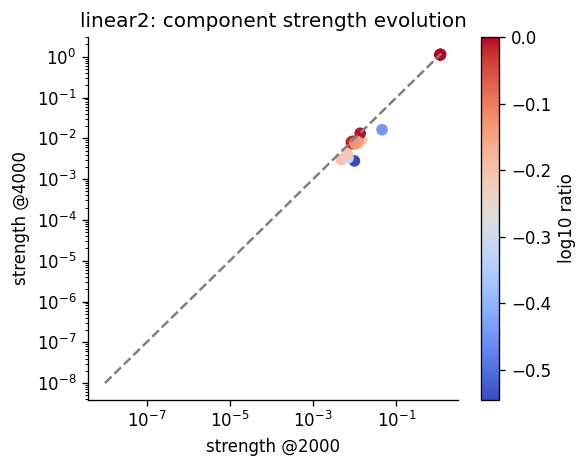

,layer,component,strength_2000,strength_4000,log10_ratio_4000_over_2000
4,linear1,4,1.125322,1.126209,0.000342
8,linear1,8,1.138660,1.137914,-0.000285
18,linear1,18,1.147134,1.146286,-0.000321
1,linear1,1,1.129894,1.128380,-0.000582
5,linear1,5,1.125896,1.124016,-0.000726
14,linear1,14,0.013519,0.013302,-0.007024
11,linear1,11,0.008326,0.008141,-0.009761
12,linear1,12,0.008836,0.008427,-0.020597
9,linear1,9,0.008503,0.007228,-0.070548
3,linear1,3,0.010728,0.008735,-0.089259


In [19]:
# -------------------------
# Checkpoint comparison
# -------------------------

ckpt_2000 = RUN_DIR / 'model_2000.pth'

if ckpt_2000.exists():
    _, model_2000 = build_component_model_from_checkpoint(ckpt_2000)

    def layer_metrics_table(model: ComponentModel) -> pd.DataFrame:
        rows = []
        for layer_name, comp in model.components.items():
            m, _ = calc_layer_alignment(
                target_weight=model.target_weight(layer_name).detach().cpu(),
                component_v=comp.V.detach().cpu(),
                component_u=comp.U.detach().cpu(),
            )
            rows.append({'layer': layer_name, **m})
        return pd.DataFrame(rows)

    align_2000 = layer_metrics_table(model_2000)
    align_4000 = layer_metrics_table(component_model)

    align_2000['checkpoint'] = 'model_2000'
    align_4000['checkpoint'] = 'model_4000'

    align_compare = pd.concat([align_2000, align_4000], ignore_index=True)
    display(align_compare)

    s2000 = component_strength_df(model_2000).rename(columns={'strength': 'strength_2000'})
    s4000 = component_strength_df(component_model).rename(columns={'strength': 'strength_4000'})
    merged = s2000[['layer', 'component', 'strength_2000']].merge(
        s4000[['layer', 'component', 'strength_4000']],
        on=['layer', 'component'],
        how='inner',
    )
    merged['log10_ratio_4000_over_2000'] = np.log10((merged['strength_4000'] + 1e-12) / (merged['strength_2000'] + 1e-12))

    for layer, g in merged.groupby('layer'):
        plt.figure(figsize=(5, 4))
        plt.scatter(g['strength_2000'], g['strength_4000'], c=g['log10_ratio_4000_over_2000'], cmap='coolwarm')
        lim = max(g['strength_2000'].max(), g['strength_4000'].max()) * 1.05
        plt.plot([1e-8, lim], [1e-8, lim], '--', color='gray')
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('strength @2000')
        plt.ylabel('strength @4000')
        plt.title(f'{layer}: component strength evolution')
        plt.colorbar(label='log10 ratio')
        plt.tight_layout()
        plt.show()

    display(merged.sort_values(['layer', 'log10_ratio_4000_over_2000'], ascending=[True, False]).groupby('layer').head(10))
else:
    print('No model_2000.pth found; skipping checkpoint evolution section.')


### Result Analysis

- From `model_2000` to `model_4000`, faithfulness improves while effective components typically shrink (e.g., ~11 -> ~7), suggesting consolidation/pruning.
- Core high-strength components remain stable across checkpoints; changes are mainly in weaker tail components.
- This is consistent with late-stage specialization rather than wholesale mechanism change.


## 12) Auto Summary Report

This compiles key findings from the analysis into a concise diagnostic snapshot.


In [20]:
# -------------------------
# Auto summary report
# -------------------------

summary = {}

# Final eval losses from metrics.jsonl
for key in [
    'loss/FaithfulnessLoss',
    'loss/UnmaskedReconLoss',
    'loss/CIMaskedReconLoss',
    'loss/CIMaskedReconLayerwiseLoss',
    'target_solution_error/total',
    'target_solution_error/linear1',
    'target_solution_error/linear2',
    'l0/0.1_linear1',
    'l0/0.1_linear2',
]:
    if key in metrics_df.columns:
        val = metrics_df[key].dropna()
        if len(val) > 0:
            summary[key] = float(val.iloc[-1])

# Alignment metrics at model_4000
for _, row in align_df.iterrows():
    layer = row['layer']
    summary[f'align/{layer}/MMCS'] = float(row['MMCS'])
    summary[f'align/{layer}/ML2R'] = float(row['ML2R'])
    summary[f'align/{layer}/coverage@0.99'] = float(row['coverage@0.99'])
    summary[f'align/{layer}/off_target_leakage'] = float(row['off_target_leakage'])

# Effective components
for layer, g in strength_df.groupby('layer'):
    s = g['strength'].to_numpy()
    summary[f'strength/{layer}/effective_components@1pct_max'] = float(np.sum(s > 0.01 * np.max(s)))

summary_series = pd.Series(summary).sort_index()
display(summary_series)

report_lines = [
    '# Diagnostic Summary',
    '',
    f"- Run: `{RUN_ID}`",
    f"- Checkpoint analyzed: `{CHECKPOINT_PATH.name}`",
    f"- Faithfulness loss: `{summary.get('loss/FaithfulnessLoss', float('nan')):.3e}`",
    f"- Unmasked recon loss: `{summary.get('loss/UnmaskedReconLoss', float('nan')):.3e}`",
    f"- CI masked recon loss: `{summary.get('loss/CIMaskedReconLoss', float('nan')):.3e}`",
    f"- Target solution error (total): `{summary.get('target_solution_error/total', float('nan')):.2f}`",
]

for layer in component_model.components.keys():
    mmcs = summary.get(f'align/{layer}/MMCS', float('nan'))
    ml2r = summary.get(f'align/{layer}/ML2R', float('nan'))
    eff = summary.get(f'strength/{layer}/effective_components@1pct_max', float('nan'))
    report_lines.append(f"- {layer}: MMCS={mmcs:.4f}, ML2R={ml2r:.4f}, effective_components={eff:.0f}")

display(Markdown(chr(10).join(report_lines)))


align/linear1/ML2R                                0.998573
align/linear1/MMCS                                0.999928
align/linear1/coverage@0.99                       1.000000
align/linear1/off_target_leakage                  0.075564
align/linear2/ML2R                                0.625869
align/linear2/MMCS                                0.632760
align/linear2/coverage@0.99                       0.000000
align/linear2/off_target_leakage                  0.138790
l0/0.1_linear1                                    0.205142
l0/0.1_linear2                                    0.253755
loss/CIMaskedReconLayerwiseLoss                   0.000184
loss/CIMaskedReconLoss                            0.000325
loss/FaithfulnessLoss                             0.000024
loss/UnmaskedReconLoss                            0.000002
strength/linear1/effective_components@1pct_max    7.000000
strength/linear2/effective_components@1pct_max    7.000000
target_solution_error/linear1                     0.0000

# Diagnostic Summary

- Run: `s-c6eda15c`
- Checkpoint analyzed: `model_4000.pth`
- Faithfulness loss: `2.424e-05`
- Unmasked recon loss: `1.989e-06`
- CI masked recon loss: `3.255e-04`
- Target solution error (total): `1.00`
- linear1: MMCS=0.9999, ML2R=0.9986, effective_components=7
- linear2: MMCS=0.6328, ML2R=0.6259, effective_components=7

### Result Analysis

- The summary table is the compact dashboard for this run.
- Key takeaways should match the deeper sections:
  - very low faithfulness/recon errors,
  - near-perfect `linear1` geometric recovery,
  - sparse effective component usage,
  - only one remaining target-pattern CI mismatch.


## 13) Optional Extensions

High-value next analyses you can add quickly:

1. Run this same notebook on multiple seeds and compare distributions, not just point metrics.
2. Add hidden-layer identity variant (`tms_5-2-id`) and test expected `m2 + m1` active components.
3. Add clustering over cross-layer co-activation to recover multi-layer mechanisms.
4. Add bootstrap confidence intervals for knockout/synergy metrics.
5. Export all generated figures to `RUN_DIR/analysis_notebook_figures/`.
